In [71]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor 
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder

In [72]:
X_train = pd.read_csv("data/challenge_train_features.csv", index_col=0)
y_train = pd.read_csv("data/challenge_train_revenue.csv", index_col=0)
X_test = pd.read_csv("data/challenge_test_features.csv", index_col=0)

In [73]:
def get_first_genre(X):
    """
    Extrait le premier genre de la liste des genres (séparés par des virgules)
    Example: 'Action, Adventure, Drama' -> 'Action'
    """
    X = X.copy()
    # Divise la chaîne par les virgules et prend le premier élément
    X['genre'] = X['genre'].str.split(',').str[0]
    # Gestion des valeurs manquantes
    X['genre'] = X['genre'].fillna('Unknown')
    return X[['genre']]

In [74]:
X_train["first_genre"] = get_first_genre(X_train)
get_first_genre(X_train)['genre'].value_counts()

genre
Drama              531
Comedy             407
Action             333
Adventure          122
Horror             117
Crime              100
Thriller            83
Documentary         52
Animation           50
Romance             44
Fantasy             39
Family              25
Science Fiction     25
Mystery             23
Music               14
War                 13
Western              8
History              7
Unknown              5
Foreign              2
Name: count, dtype: int64

In [75]:
df = X_train.join(y_train)

In [76]:
# Moyenne globale du revenu
moyenne_globale = df["revenue"].mean()

# Moyenne par catégorie
revenu_par_genre = df.groupby("first_genre")["revenue"].mean()

# Pourcentage d'écart par rapport à la moyenne globale
pourcentage_ecart = (revenu_par_genre / moyenne_globale - 1) * 100

# Résumé clair
resultat = pd.DataFrame({
    "revenu_moyen": revenu_par_genre,
    "écart_%_par_rapport_moyenne": pourcentage_ecart
})

print(resultat)


                 revenu_moyen  écart_%_par_rapport_moyenne
first_genre                                               
Action             98,355,635                           47
Adventure         194,742,190                          191
Animation         175,585,574                          163
Comedy             49,338,856                          -26
Crime              36,216,175                          -46
Documentary         4,473,137                          -93
Drama              36,118,629                          -46
Family            116,950,851                           75
Fantasy            98,959,399                           48
Foreign               140,650                         -100
History            41,134,607                          -38
Horror             46,634,362                          -30
Music              32,544,493                          -51
Mystery            43,035,931                          -36
Romance            49,135,495                          -

stats du revenus pour les budgets <= 20 000
count           561
mean     11,663,543
std      24,764,233
min               1
25%         206,728
50%       2,003,822
75%      11,472,454
max     239,606,210
Name: revenue, dtype: float64


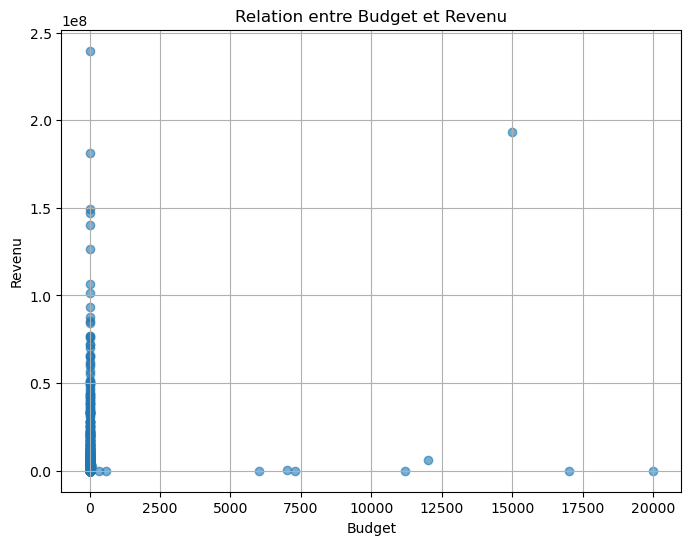

stats pour les budgets > 100 millions
count              79
mean      501,242,139
std       327,360,376
min        48,668,907
25%       262,011,116
50%       408,579,038
75%       702,211,580
max     1,519,557,910
Name: revenue, dtype: float64
count            79
mean    158,639,241
std      51,595,688
min     102,000,000
25%     120,000,000
50%     149,000,000
75%     185,000,000
max     380,000,000
Name: budget, dtype: float64


<Figure size 640x480 with 0 Axes>

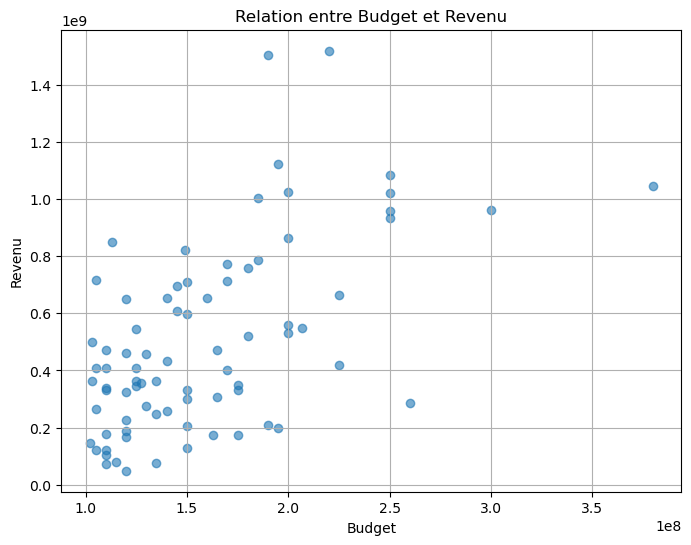

In [77]:
import matplotlib.pyplot as plt
pd.set_option('display.float_format', '{:,.0f}'.format)

#garder les budget entre 0 et 100000
df_temp = df[df['budget'] <= 20000]
print("stats du revenus pour les budgets <= 20 000")
print(df_temp["revenue"].describe())
plt.figure(figsize=(8,6))
plt.scatter(df_temp['budget'], df_temp['revenue'], alpha=0.6)
plt.xlabel('Budget')
plt.ylabel('Revenu')
plt.title('Relation entre Budget et Revenu')
plt.grid(True)
plt.show()


print("stats pour les budgets > 100 millions")
df_temp2 = df[df['budget'] > 100000000].copy()
print(df_temp2["revenue"].describe())



plt.clf() 
print(df_temp2["budget"].describe())
fig = plt.figure(figsize=(8,6))
plt.scatter(df_temp2['budget'], df_temp2['revenue'], alpha=0.6)
plt.xlabel('Budget')
plt.ylabel('Revenu')
plt.title('Relation entre Budget et Revenu')
plt.grid(True)
plt.show()


In [80]:
#creer un df en retirant les budgets nuls
df_nonzero_budget = df[df['budget'] > 0].copy()

# Moyenne globale du revenu
moyenne_globale = df_nonzero_budget["revenue"].mean()

# Moyenne par catégorie
revenu_par_genre = df_nonzero_budget.groupby("first_genre")["revenue"].mean()

#compte par catégorie
compte_par_genre = df_nonzero_budget['first_genre'].value_counts()

# Pourcentage d'écart par rapport à la moyenne globale
pourcentage_ecart = (revenu_par_genre / moyenne_globale - 1) * 100

# Résumé clair
resultat = pd.DataFrame({
    "revenu_moyen": revenu_par_genre,
    "écart_%_par_rapport_moyenne": pourcentage_ecart,"compte": compte_par_genre
})

resultat = resultat.sort_values(by="écart_%_par_rapport_moyenne", ascending=False)

print(resultat)

                 revenu_moyen  écart_%_par_rapport_moyenne  compte
first_genre                                                       
Animation         221,636,823                          154      39
Adventure         213,494,628                          144     109
Family            180,192,368                          106      15
Science Fiction   172,083,737                           97      23
Fantasy           126,803,444                           45      29
Action            115,986,662                           33     273
Thriller           74,864,532                          -14      60
Comedy             66,390,306                          -24     275
Romance            57,464,632                          -34      34
Horror             53,966,038                          -38     100
Drama              49,534,072                          -43     359
History            47,956,411                          -45       6
Mystery            45,549,288                          -48    

In [ ]:
df = X_train.join(y_train)
df["genres_list"] = df["genres"].apply(lambda x: x.split(",") if isinstance(x, str) else [])
